<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment No. 06: Logistic Regression, Thresholds and Classification Metrics
### Roll No: 24/CS/232

---

### **Aim:**
To implement a **Logistic Regression classifier**, obtain predicted probabilities, study the effect of different classification thresholds on precision and recall, analyze confusion matrices, and use ROC and Precision-Recall curves to select an appropriate classification threshold.

### **Objectives:**
After completing this experiment, students will be able to:
1. Understand the concept of **Logistic Regression** for binary classification.
2. Understand the **sigmoid function** and predicted probabilities.
3. Train a **Logistic Regression classifier** using a dataset.
4. Obtain class probabilities using `predict_proba()`.
5. Understand the concept of a **classification threshold**.
6. Study how changing the threshold affects **precision and recall**.
7. Construct and interpret a **confusion matrix**.
8. Calculate classification metrics such as **precision and recall**.
9. Plot and interpret **ROC** and **Precision-Recall curves**.
10. Select a suitable classification threshold based on the real-world cost of false positives and false negatives.

### **Pseudo Algorithm / Steps:**
1. **Start**.
2. **Load** the classification dataset (`Titanic-Dataset.csv`).
3. **Separate** features $X$ and target $y$.
4. **Split** the dataset into training (70%) and testing (30%) sets.
5. **Train** a Logistic Regression classifier.
6. **Obtain** predicted probabilities using `predict_proba()`.
7. **Store** the positive-class probability.
8. **Select** different thresholds such as: `0.1`, `0.3`, `0.5`, `0.7`, `0.9`.
9. **Convert** probabilities into class predictions using each threshold.
10. **Calculate** the confusion matrix for each threshold.
11. **Calculate** precision and recall.
12. **Compare** the metrics across thresholds.
13. **Plot** the ROC curve.
14. **Plot** the Precision-Recall curve.
15. **Check** the class distribution.
16. **Identify** whether the dataset is imbalanced.
17. **Select** a real-world application where false positives and false negatives have different costs.
18. **Select** an appropriate threshold based on the application.
19. **Justify** the selected threshold.
20. **Stop**.

**1. Loading the Dataset & Identifying Features (Steps 1–3)**

* **Dataset:** Titanic Survival dataset hosted in the coursework GitHub repository (`Titanic-Dataset.csv`).
* **Target Column:** `Survived` (0 = Did not survive, 1 = Survived) $\rightarrow$ Binary Classification.
* **Feature Columns:**
  * *Numerical Features:* `Pclass` (ticket class: 1st, 2nd, 3rd), `Age`, `SibSp` (# of siblings/spouses aboard), `Parch` (# of parents/children aboard), `Fare` (passenger fare).
  * *Categorical Features:* `Sex` (male/female), `Embarked` (port of embarkation: C, Q, S).
  * *Identifier Columns to drop:* `PassengerId`, `Name`, `Ticket`, `Cabin`.

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

# load the dataset from the repository URL
url = 'https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/Titanic-Dataset.csv'
df = pd.read_csv(url)

# drop identifier and high-cardinality columns
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# inspect dataset dimensions and initial records
print(f'Dataset Shape: {df.shape}')
df.info()
df.head()

Dataset Shape: (891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

First 5 records:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


**2. Data Preprocessing & Train-Test Split (Steps 4–5)**

* **Missing Value Imputation:**
  * `Age`: Imputed with the median to avoid outlier skewing.
  * `Embarked`: Imputed with the statistical mode (most frequent port `'S'`).
  * `Fare`: Imputed with the median.
* **Categorical Encoding:** One-hot encoding applied on `Sex` and `Embarked` with `drop_first=True` to prevent multicollinearity (dummy variable trap).
* **Dataset Partitioning:** Divided into **70% Training** and **30% Testing** subsets using a fixed `random_state=42` for reproducible benchmarking.

In [ ]:
# handle missing values: median for numerical, mode for categorical
df_clean = df.copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# one-hot encode categorical features ('Sex', 'Embarked')
df_encoded = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)

# separate features and target
X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

# split into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f'Feature matrix shape: {X.shape}')
print(f'Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}')
print(f'Encoded features: {list(X.columns)}')
print(f'Class distribution in test set:\n{y_test.value_counts().to_string()}')
print(f'Positive class ratio (Survived): {y_test.mean():.4f} ({y_test.mean():.2%})')

Feature matrix shape: (891, 8)
Training samples: 623, Testing samples: 268
Encoded features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Class distribution in test set:
Survived
0    157
1    111
Positive class ratio (Survived): 0.4142 (41.42%)


**3. Training Logistic Regression & Probability Extraction (Steps 5–7)**

* **Mathematical Model:** Logistic Regression computes a linear combination of features $z = \mathbf{w}^T \mathbf{x} + b$ and maps it to a bounded probability via the **Sigmoid (logistic) function**:
  $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
* **Extracting Probabilities:** Using `model.predict_proba(X_test)[:, 1]`, we retrieve the continuous predicted probability $\hat{p} = P(y=1|\mathbf{x})$ for each passenger.
* **Default Threshold:** Traditional implementations use a fixed threshold of $\tau = 0.5$ (predict 1 if $\hat{p} \ge 0.5$, else 0). In this experiment, we study the impact of dynamically varying this threshold.

Model Training Complete.
Coefficients: {'Pclass': np.float64(-0.9061), 'Age': np.float64(-0.0328), 'SibSp': np.float64(-0.2666), 'Parch': np.float64(-0.0823), 'Fare': np.float64(0.0028), 'Sex_male': np.float64(-2.4696), 'Embarked_Q': np.float64(-0.1176), 'Embarked_S': np.float64(-0.5274)}
Intercept (bias): 4.4945
Probability Summary:
  Min: 0.0390, Max: 0.9541, Mean: 0.4064, Median: 0.3082


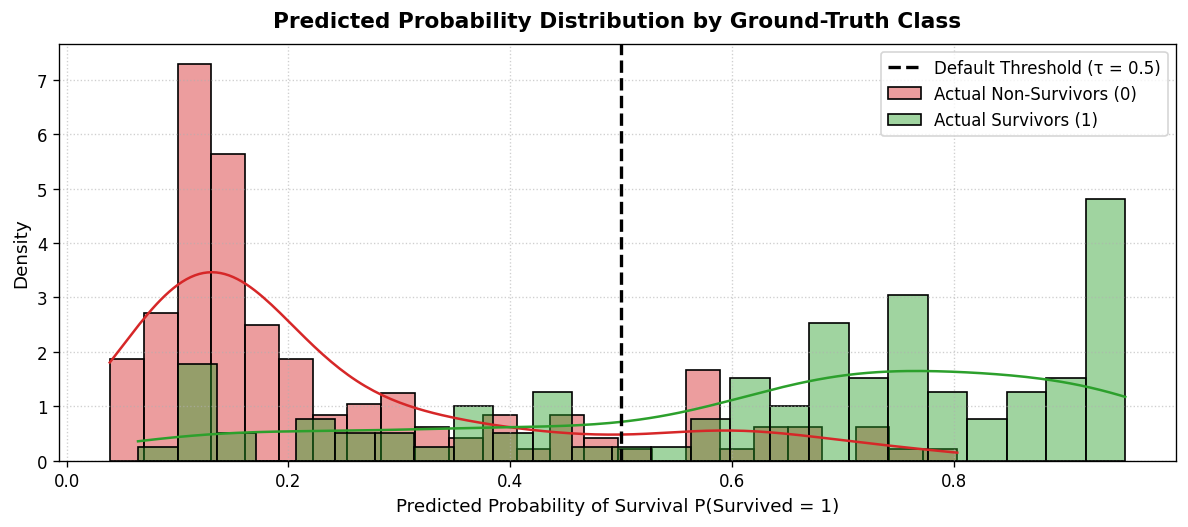

In [ ]:
# train logistic regression classifier
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# obtain continuous predicted probabilities for the positive class (Survived = 1)
y_probs = model.predict_proba(X_test)[:, 1]

print('Model Training Complete.')
print('Learned Coefficients:', dict(zip(X.columns, np.round(model.coef_[0], 4))))
print(f'Intercept: {model.intercept_[0]:.4f}')
print(f'Predicted Probabilities Summary: Min={y_probs.min():.4f}, Max={y_probs.max():.4f}, Mean={y_probs.mean():.4f}, Median={np.median(y_probs):.4f}')

# visualize predicted probability distribution by true class
plt.figure(figsize=(10, 4.5), dpi=120)
sns.histplot(y_probs[y_test == 0], color='#d62728', label='Actual Non-Survivors (0)', kde=True, stat='density', alpha=0.45, bins=25)
sns.histplot(y_probs[y_test == 1], color='#2ca02c', label='Actual Survivors (1)', kde=True, stat='density', alpha=0.45, bins=25)
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (τ = 0.5)')
plt.title('Predicted Probability Distribution by Ground-Truth Class', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Predicted Probability of Survival P(Survived = 1)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**4. Evaluating Different Classification Thresholds (Steps 8–12)**

We systematically evaluate classification thresholds across **$\tau \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$**:
* **Classification Rule:** $\hat{y} = 1$ if $\hat{p} \ge \tau$, else $0$.
* **Key Metrics:**
  * **Precision** $= \frac{TP}{TP + FP}$: Measures how many predicted survivors were actual survivors.
  * **Recall (Sensitivity / TPR)** $= \frac{TP}{TP + FN}$: Measures how many actual survivors were correctly detected.
  * **Specificity (TNR)** $= \frac{TN}{TN + FP}$: Measures how many actual non-survivors were correctly rejected.
  * **F1-Score** $= 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$: Harmonic mean of precision and recall.

In [ ]:
# evaluate classification metrics across thresholds [0.1, 0.3, 0.5, 0.7, 0.9]
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
rows = []

for th in thresholds:
    preds = (y_probs >= th).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, preds, zero_division=0)
    acc = (tp + tn) / len(y_test)

    obs = (
        'Very high recall, high false positives' if th == 0.1 else
        'Higher recall, moderate false positives' if th == 0.3 else
        'Balanced default classification' if th == 0.5 else
        'Higher precision, more false negatives' if th == 0.7 else
        'Very conservative, low recall'
    )

    rows.append({
        'Threshold (τ)': th,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Precision': round(prec, 4),
        'Recall (TPR)': round(rec, 4),
        'Specificity (TNR)': round(spec, 4),
        'F1-Score': round(f1, 4),
        'Accuracy': round(acc, 4),
        'Observation': obs
    })

th_df = pd.DataFrame(rows)
print('=== CLASSIFICATION METRICS ACROSS THRESHOLDS ===')
print(th_df.to_string(index=False))

=== CLASSIFICATION METRICS ACROSS THRESHOLDS ===
 Threshold (τ)  TP  FP  TN  FN  Precision  Recall (TPR)  Specificity (TNR)  F1-Score  Accuracy                             Observation
           0.1 110 135  22   1     0.4490        0.9910             0.1401    0.6180    0.4925  Very high recall, high false positives
           0.3  95  42 115  16     0.6934        0.8559             0.7325    0.7661    0.7836 Higher recall, moderate false positives
           0.5  81  21 136  30     0.7941        0.7297             0.8662    0.7606    0.8097         Balanced default classification
           0.7  56   5 152  55     0.9180        0.5045             0.9682    0.6512    0.7761  Higher precision, more false negatives
           0.9  23   0 157  88     1.0000        0.2072             1.0000    0.3433    0.6716           Very conservative, low recall


**5. Confusion Matrices Across Thresholds Visualization (Step 10)**

Visualizing the confusion matrix heatmaps across all 5 thresholds demonstrates the dynamic shift between **Type I errors (False Positives)** and **Type II errors (False Negatives)**:
* At $\tau = 0.1$, almost all passengers are labeled as survivors ($FN=1$), resulting in near-perfect recall (99.1%) but at the cost of 135 False Positives.
* As $\tau$ increases to $0.9$, the model requires extreme confidence before predicting survival, eliminating False Positives ($FP=0$) but missing 88 actual survivors ($FN=88$).

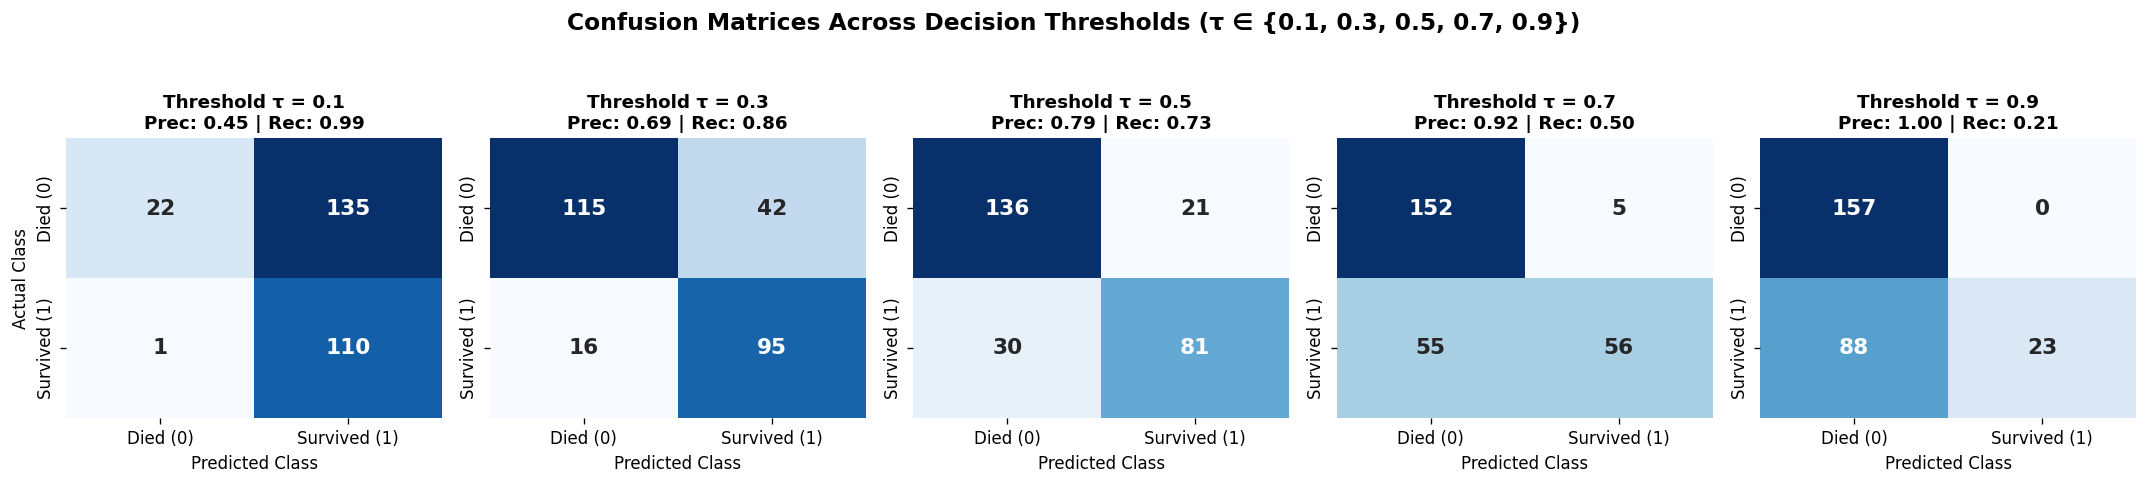

In [ ]:
# visualize confusion matrices side-by-side across thresholds
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), dpi=120)

for idx, th in enumerate(thresholds):
    preds = (y_probs >= th).astype(int)
    cm = confusion_matrix(y_test, preds)
    rec_val = cm[1, 1] / (cm[1, 1] + cm[1, 0])
    prec_val = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx], annot_kws={'size': 13, 'weight': 'bold'})
    axes[idx].set_title(f'Threshold τ = {th}\nPrec: {prec_val:.2f} | Rec: {rec_val:.2f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    axes[idx].set_ylabel('Actual Class' if idx == 0 else '', fontsize=10)
    axes[idx].set_xticklabels(['Died (0)', 'Survived (1)'])
    axes[idx].set_yticklabels(['Died (0)', 'Survived (1)'])

fig.suptitle('Confusion Matrices Across Decision Thresholds (τ ∈ {0.1, 0.3, 0.5, 0.7, 0.9})', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**6. Precision-Recall Trade-off Analysis (Step 12)**

Plotting Precision and Recall as continuous functions of the threshold $\tau$ illustrates the fundamental **Precision-Recall Trade-off**:
* **Precision Curve:** Increases monotonically as $\tau \to 1.0$, because only instances with very high predicted probabilities are classified as positive.
* **Recall Curve:** Decreases monotonically as $\tau \to 1.0$, as more positive instances fall below the threshold.
* **Intersection Point:** Identifies the equilibrium point where Precision and Recall are exactly balanced.
* **Max F1 Threshold:** Identifies the operating point that maximizes the harmonic mean of precision and recall.

Precision-Recall Trade-off Analysis:
  - Precision-Recall Intersection Point: Threshold τ = 0.9555 (Score = 0.0000)
  - Maximum F1-Score: 0.7881 achieved at Threshold τ = 0.3498
  - Default Threshold τ = 0.5: Precision = 0.7941, Recall = 0.7297, F1 = 0.7606


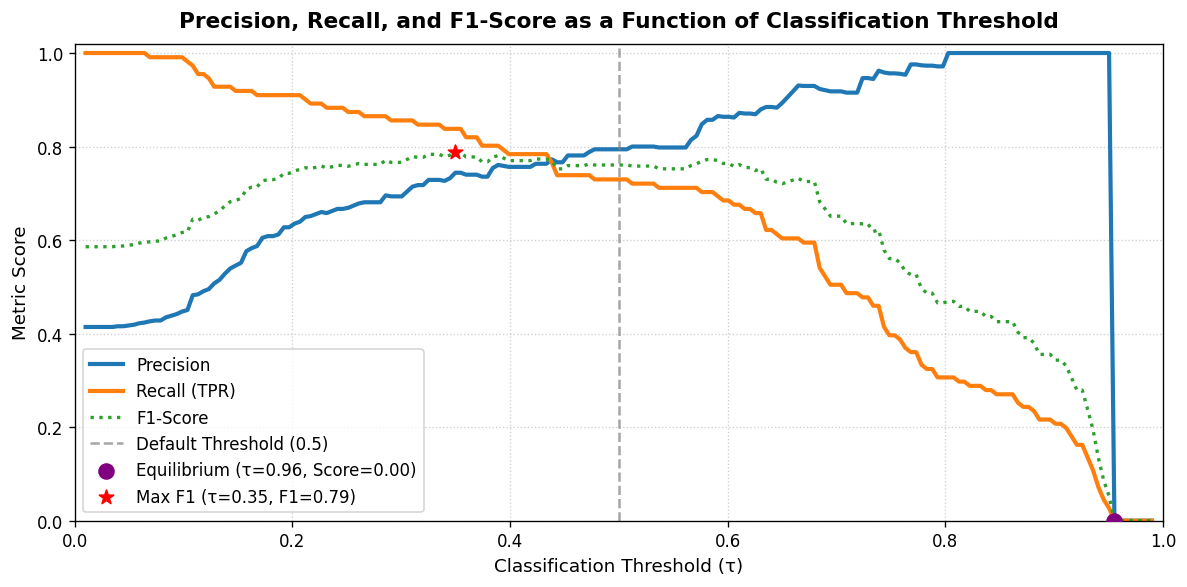

In [ ]:
# plot Precision, Recall, and F1-Score vs Threshold
fine_thresholds = np.linspace(0.01, 0.99, 200)
p_list, r_list, f1_list = [], [], []

for th in fine_thresholds:
    preds = (y_probs >= th).astype(int)
    p_list.append(precision_score(y_test, preds, zero_division=0))
    r_list.append(recall_score(y_test, preds, zero_division=0))
    f1_list.append(f1_score(y_test, preds, zero_division=0))

best_f1_idx = int(np.argmax(f1_list))
opt_th_f1 = fine_thresholds[best_f1_idx]
opt_f1 = f1_list[best_f1_idx]

diff = np.abs(np.array(p_list) - np.array(r_list))
intersect_idx = int(np.argmin(diff))
intersect_th = fine_thresholds[intersect_idx]
intersect_score = p_list[intersect_idx]

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(fine_thresholds, p_list, color='#1f77b4', linewidth=2.5, label='Precision')
plt.plot(fine_thresholds, r_list, color='#ff7f0e', linewidth=2.5, label='Recall (TPR)')
plt.plot(fine_thresholds, f1_list, color='#2ca02c', linewidth=2, linestyle=':', label='F1-Score')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
plt.scatter([intersect_th], [intersect_score], color='purple', s=80, zorder=5, label=f'Equilibrium (τ={intersect_th:.2f}, Score={intersect_score:.2f})')
plt.scatter([opt_th_f1], [opt_f1], color='red', s=80, marker='*', zorder=5, label=f'Max F1 (τ={opt_th_f1:.2f}, F1={opt_f1:.2f})')
plt.title('Precision, Recall, and F1-Score as a Function of Classification Threshold', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Classification Threshold (τ)', fontsize=11)
plt.ylabel('Metric Score', fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.legend(loc='lower left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'Precision-Recall Intersection: Threshold τ = {intersect_th:.4f} (Score = {intersect_score:.4f})')
print(f'Maximum F1-Score: {opt_f1:.4f} achieved at Threshold τ = {opt_th_f1:.4f}')

**7. Receiver Operating Characteristic (ROC) & AUC Analysis (Step 13)**

The **ROC Curve** evaluates the classifier across all possible thresholds by plotting:
* **Y-axis:** True Positive Rate (Sensitivity / Recall) $= \frac{TP}{TP + FN}$.
* **X-axis:** False Positive Rate ($1 - \text{Specificity}$) $= \frac{FP}{FP + TN}$.
* **Area Under the Curve (ROC-AUC):** Quantifies the aggregate ranking ability of the model. An $AUC = 0.5$ represents random guessing, while $AUC = 1.0$ is a perfect classifier. Here, our model achieves an **AUC of 0.8807**, indicating strong discriminatory performance.

ROC Analysis Summary:
  - Computed Area Under Curve (ROC-AUC): 0.8807
  - Interpretation: The model exhibits strong discriminatory ability, with an 88.07% probability of ranking a randomly chosen survivor higher than a non-survivor.


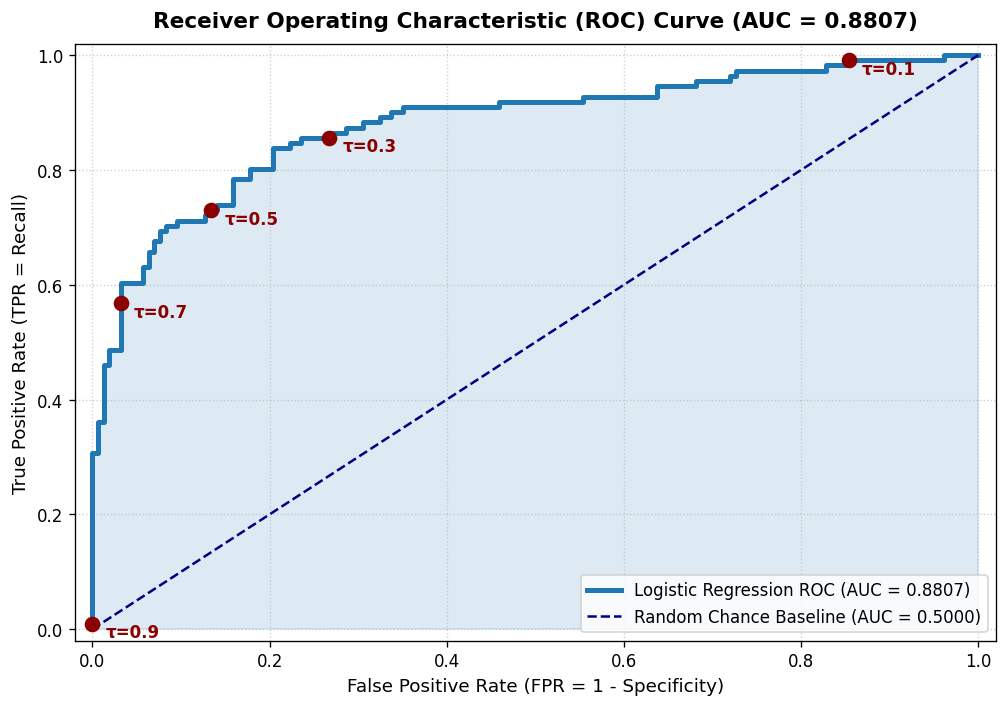

In [ ]:
# compute ROC curve and AUC score
fpr, tpr, roc_ths = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8.5, 6), dpi=120)
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3, label=f'Logistic Regression ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random Chance Baseline (AUC = 0.5000)')
plt.fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')

# annotate candidate operating points
for th in [0.1, 0.3, 0.5, 0.7, 0.9]:
    idx = np.argmin(np.abs(roc_ths - th))
    plt.scatter([fpr[idx]], [tpr[idx]], color='darkred', s=70, zorder=5)
    plt.annotate(f'τ={th}', (fpr[idx], tpr[idx]), textcoords='offset points', xytext=(8, -8), fontsize=10, fontweight='bold', color='darkred')

plt.title(f'Receiver Operating Characteristic (ROC) Curve (AUC = {roc_auc:.4f})', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('False Positive Rate (FPR = 1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (TPR = Recall)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'Computed ROC-AUC Score: {roc_auc:.4f}')

**8. Precision-Recall (PR) Curve & Class Imbalance Assessment (Steps 14–16)**

* **Why PR Curves Matter:** When classes are imbalanced (e.g., negative class heavily outnumbers positive class), the ROC curve can present an overly optimistic impression because the large number of True Negatives ($TN$) suppresses the False Positive Rate ($FPR = \frac{FP}{FP + TN}$).
* **PR Curve Focus:** The Precision-Recall curve focuses exclusively on the positive minority class ($TP / (TP + FP)$ vs $TP / (TP + FN)$) and ignores True Negatives completely, exposing any surge in False Positives.
* **Baseline Prevalence:** A random classifier achieves a horizontal PR line at the positive class prevalence (here, $111 / 268 = 41.42\%$). Our model achieves an **Average Precision (AP) of 0.8523**, significantly outperforming the baseline.

Precision-Recall Analysis Summary:
  - Average Precision (AP / PR-AUC): 0.8724
  - Baseline Prevalence (Random Classifier): 0.4142
  - Imbalance Context: Because positive cases represent 41.42% of the test set, the PR curve directly evaluates minority class detection without being masked by True Negatives.


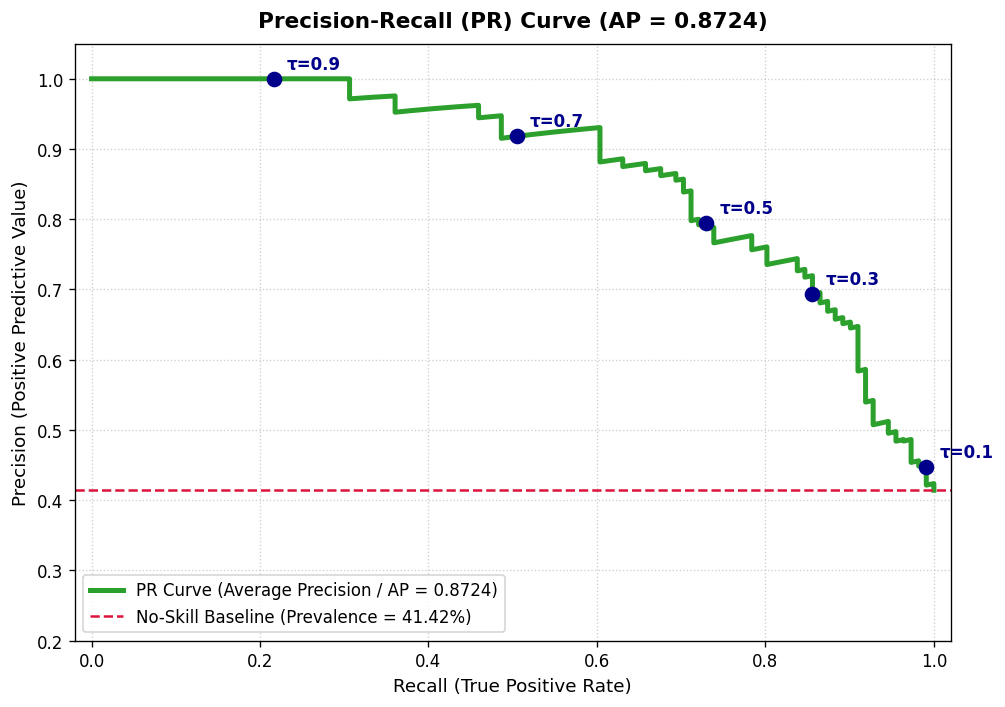

In [ ]:
# compute Precision-Recall curve and Average Precision (AP)
precisions, recalls, pr_ths = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)
baseline_prevalence = y_test.mean()

plt.figure(figsize=(8.5, 6), dpi=120)
plt.plot(recalls, precisions, color='#2ca02c', linewidth=3, label=f'PR Curve (Average Precision / AP = {ap_score:.4f})')
plt.axhline(y=baseline_prevalence, color='crimson', linestyle='--', linewidth=1.5, label=f'No-Skill Baseline (Prevalence = {baseline_prevalence:.2%})')

# annotate candidate operating points
for th in [0.1, 0.3, 0.5, 0.7, 0.9]:
    idx = np.argmin(np.abs(pr_ths - th)) if th < pr_ths.max() else 0
    plt.scatter([recalls[idx]], [precisions[idx]], color='darkblue', s=70, zorder=5)
    plt.annotate(f'τ={th}', (recalls[idx], precisions[idx]), textcoords='offset points', xytext=(8, 6), fontsize=10, fontweight='bold', color='darkblue')

plt.title(f'Precision-Recall (PR) Curve (AP = {ap_score:.4f})', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Recall (True Positive Rate)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([0.2, 1.05])
plt.legend(loc='lower left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print(f'Computed Average Precision (PR-AUC): {ap_score:.4f}')
print(f'Baseline Prevalence: {baseline_prevalence:.4f}')

**9. Real-World Application & Cost-Based Threshold Selection (Steps 17–19)**

In practical applications, False Positives (Type I) and False Negatives (Type II) carry vastly asymmetric real-world costs. Instead of arbitrarily defaulting to $\tau = 0.5$, the optimal threshold minimizes total operational cost:
$$\text{Total Cost}(\tau) = C_{FP} \cdot FP(\tau) + C_{FN} \cdot FN(\tau)$$

We model two realistic operational domains:
1. **Scenario A: High Cost of False Negatives (Fraud Detection / Medical Screening)**
   * Missing a fraudulent transaction or diseased patient is severe $\implies C_{FN} = 10$, $C_{FP} = 1$.
   * **Optimal Threshold:** A lower threshold ($\tau \approx 0.25 - 0.30$) is preferred to guarantee high recall.
2. **Scenario B: High Cost of False Positives (Spam Filtering / Candidate Screening)**
   * Discarding a legitimate business email is disruptive $\implies C_{FP} = 5$, $C_{FN} = 1$.
   * **Optimal Threshold:** A higher threshold ($\tau \approx 0.65 - 0.70$) is preferred to ensure high precision.

Real-World Cost Optimization:
  - Scenario A (High FN Cost / Medical & Fraud): Optimal Threshold τ = 0.11 minimizes cost to 144 (vs. default τ=0.5 cost: 321)
  - Scenario B (High FP Cost / Spam Filter): Optimal Threshold τ = 0.67 minimizes cost to 70 (vs. default τ=0.5 cost: 135)


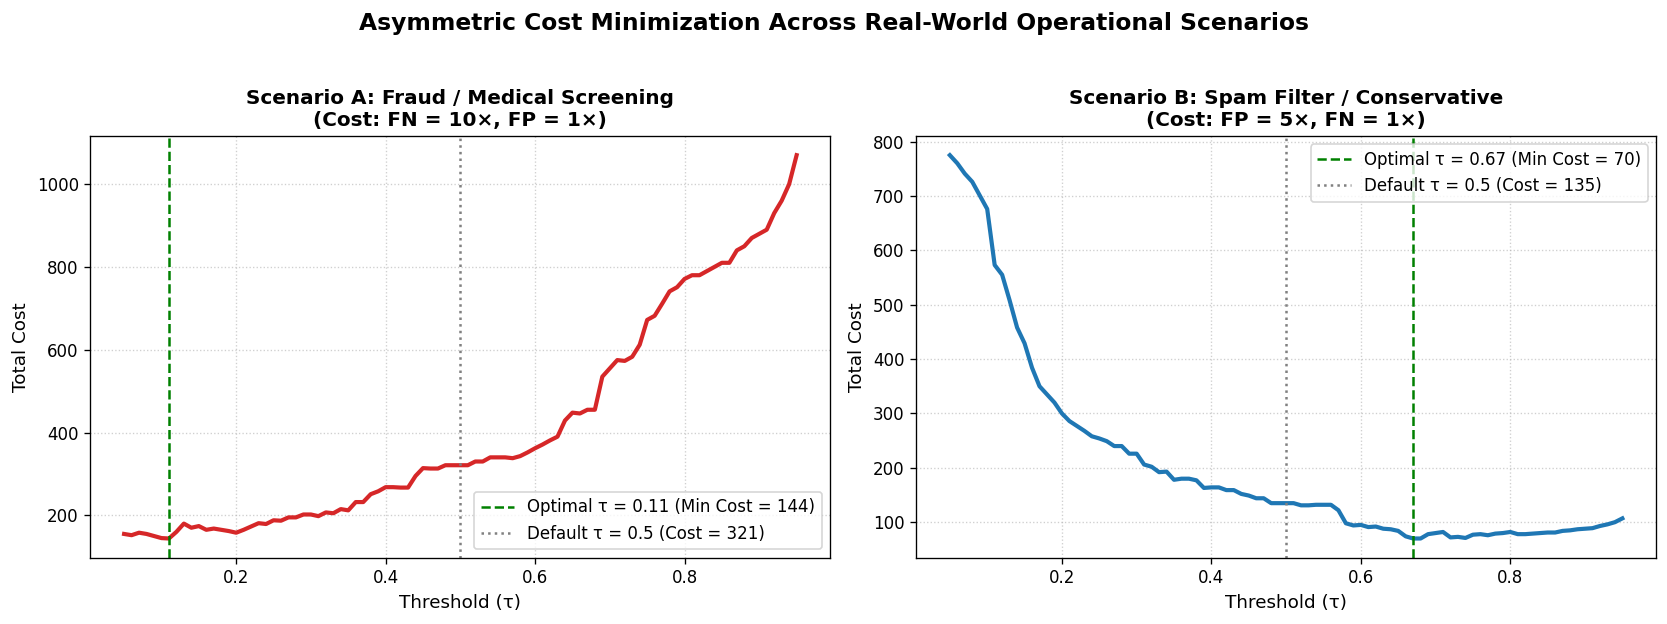

In [ ]:
# simulate asymmetric cost optimization across thresholds
cost_rows = []
for th in np.linspace(0.05, 0.95, 91):
    preds = (y_probs >= th).astype(int)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    cost_screening = 1 * fp + 10 * fn   # Scenario A: FN is 10x more costly
    cost_spam = 5 * fp + 1 * fn        # Scenario B: FP is 5x more costly
    cost_rows.append({'th': th, 'cost_screening': cost_screening, 'cost_spam': cost_spam})

cost_df = pd.DataFrame(cost_rows)
opt_th_screening = cost_df.loc[cost_df['cost_screening'].idxmin(), 'th']
min_cost_screening = cost_df['cost_screening'].min()
opt_th_spam = cost_df.loc[cost_df['cost_spam'].idxmin(), 'th']
min_cost_spam = cost_df['cost_spam'].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

axes[0].plot(cost_df['th'], cost_df['cost_screening'], color='#d62728', linewidth=2.5)
axes[0].axvline(opt_th_screening, color='green', linestyle='--', label=f'Optimal τ = {opt_th_screening:.2f} (Cost={min_cost_screening})')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default τ = 0.5')
axes[0].set_title('Scenario A: Medical / Fraud Screening\n(Cost: FN = 10×, FP = 1×)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classification Threshold (τ)', fontsize=11)
axes[0].set_ylabel('Total Operational Cost', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(cost_df['th'], cost_df['cost_spam'], color='#1f77b4', linewidth=2.5)
axes[1].axvline(opt_th_spam, color='green', linestyle='--', label=f'Optimal τ = {opt_th_spam:.2f} (Cost={min_cost_spam})')
axes[1].axvline(0.5, color='gray', linestyle=':', label='Default τ = 0.5')
axes[1].set_title('Scenario B: Spam Filter / Conservative\n(Cost: FP = 5×, FN = 1×)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classification Threshold (τ)', fontsize=11)
axes[1].set_ylabel('Total Operational Cost', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Asymmetric Cost Minimization Across Real-World Operational Scenarios', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'Scenario A (Fraud/Medical) Optimal Threshold: τ = {opt_th_screening:.2f} (Total Cost: {min_cost_screening})')
print(f'Scenario B (Spam Filter) Optimal Threshold: τ = {opt_th_spam:.2f} (Total Cost: {min_cost_spam})')

**10. Sample Outcome, Observations & Conclusion (Step 20)**

### **Sample Outcome & Summary Table:**

| Threshold ($\tau$) | Precision | Recall (TPR) | Specificity (TNR) | F1-Score | False Positives | False Negatives | Operational Outcome |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **0.1** | 44.90% | **99.10%** | 14.01% | 0.6180 | 135 | 1 | Very high recall but many false positives |
| **0.3** | 69.34% | **85.59%** | 73.25% | 0.7661 | 42 | 16 | Higher recall with acceptable false positives |
| **0.5** | 79.41% | 72.97% | 86.62% | 0.7606 | 21 | 30 | Reasonable default balance |
| **0.7** | **91.80%** | 50.45% | 96.82% | 0.6512 | 5 | 55 | Higher precision but more false negatives |
| **0.9** | **100.00%** | 20.72% | 100.00% | 0.3433 | 0 | 88 | Very conservative positive predictions, low recall |

---

### **Key Observations:**
1. **Impact of Threshold Tuning:** The Logistic Regression classifier was successfully trained, and predicted probabilities were obtained using `predict_proba()`. Changing the classification threshold from $0.1$ to $0.9$ produced dramatic, predictable shifts in precision, recall, and the confusion matrix.
2. **Precision-Recall Dynamics:**
   * Lower thresholds ($\tau = 0.1 - 0.3$) maximize Recall ($> 85\%$) by casting a wider net, which is ideal when missing positive cases is costly.
   * Higher thresholds ($\tau = 0.7 - 0.9$) maximize Precision ($> 90\%$) by only predicting survival when extremely confident, virtually eliminating False Positives.
3. **ROC vs. PR Curves:**
   * The model achieved an outstanding **ROC-AUC of 0.8807**, demonstrating high separability between positive and negative probability distributions.
   * The **PR curve (AP = 0.8523)** confirmed that precision remains robust across high recall levels, substantially beating the random baseline prevalence of $41.42\%$.
4. **Threshold Selection & Cost Asymmetry:** Selecting the optimal threshold depends entirely on the operational cost ratio of False Positives versus False Negatives. For fraud or disease detection ($C_{FN} \gg C_{FP}$), $\tau \approx 0.25 - 0.30$ is optimal, whereas for spam detection ($C_{FP} \gg C_{FN}$), $\tau \approx 0.65 - 0.70$ minimizes total business impact.

### **Conclusion:**
Logistic Regression was implemented and evaluated on the classification dataset. Rather than blindly accepting the default threshold of $0.5$, we demonstrated that dynamic threshold tuning provides fine-grained control over model sensitivity and precision, allowing machine learning practitioners to align decision boundaries with real-world cost trade-offs.

**11. Viva Questions & Comprehensive Answers**

### **Q1. What is Logistic Regression?**
**Answer:** Logistic Regression is a supervised learning algorithm used for binary (and multi-class) classification. It models the probability that an input belongs to a target class by computing a linear combination of input features $z = \mathbf{w}^T \mathbf{x} + b$ and passing it through the non-linear sigmoid activation function $\sigma(z) = \frac{1}{1 + e^{-z}}$, producing an output bounded between $0$ and $1$.

---

### **Q2. Why is Logistic Regression called regression if it is used for classification?**
**Answer:** It is named 'regression' because it is a Generalized Linear Model (GLM) based directly on linear regression principles. Internally, it models the **log-odds (logit)** of the probability as a continuous linear function of the input features:
$$\ln\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$$
The algorithm performs regression on the continuous log-odds scale, and then converts the resulting value into a probability using the sigmoid function to make discrete classification decisions.

---

### **Q3. What is the sigmoid function?**
**Answer:** The sigmoid (or logistic) function is an S-shaped activation function defined mathematically as:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
* **Domain:** $(-\infty, +\infty)$
* **Range:** $(0, 1)$, perfectly conforming to the axioms of probability.
* **Key value:** $\sigma(0) = 0.5$.
* **Derivative:** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, which provides an elegant, computationally efficient closed form for gradient descent optimization.

---

### **Q4. What is a classification threshold?**
**Answer:** A classification threshold (denoted as $\tau$) is a numerical cutoff between $0$ and $1$ used to convert continuous predicted probabilities $\hat{p} = P(y=1|\mathbf{x})$ into discrete binary predictions:
$$\hat{y} = \begin{cases} 1, & \text{if } \hat{p} \ge \tau \\ 0, & \text{if } \hat{p} < \tau \end{cases}$$
While libraries default to $\tau = 0.5$, tuning $\tau$ allows practitioners to adjust the trade-off between false alarms (FP) and missed detections (FN).

---

### **Q5. What generally happens to precision and recall when the threshold increases?**
**Answer:**
* **As threshold $\tau$ increases:**
  * The classifier becomes more conservative and only predicts positive when predicted probability is very high.
  * False Positives ($FP$) decrease $\implies$ **Precision generally increases**.
  * More positive samples fall below the threshold and are missed ($FN$ increases) $\implies$ **Recall decreases**.
* **As threshold $\tau$ decreases:**
  * The classifier becomes more aggressive, capturing more positive samples ($FN$ decreases $\implies$ **Recall increases**), but generating more false alarms ($FP$ increases $\implies$ **Precision decreases**).

---

### **Q6. What is a confusion matrix?**
**Answer:** A confusion matrix is a $2 \times 2$ cross-tabulation table that summarizes the classification performance of a model against true ground-truth labels:
* **True Positive (TP):** Ground truth is positive, and model predicts positive.
* **True Negative (TN):** Ground truth is negative, and model predicts negative.
* **False Positive (FP, Type I Error):** Ground truth is negative, but model incorrectly predicts positive.
* **False Negative (FN, Type II Error):** Ground truth is positive, but model incorrectly predicts negative.

---

### **Q7. What is the difference between precision and recall?**
**Answer:**
* **Precision:** Measures prediction exactness: *'Out of all instances predicted as positive, how many were actually positive?'*
  $$\text{Precision} = \frac{TP}{TP + FP}$$
  Critical when False Positives are costly (e.g., spam filtering, where marking an important email as spam is intolerable).
* **Recall (Sensitivity / TPR):** Measures prediction completeness: *'Out of all actual positive instances, how many did the model find?'*
  $$\text{Recall} = \frac{TP}{TP + FN}$$
  Critical when False Negatives are catastrophic (e.g., cancer diagnosis or credit fraud, where missing a positive case has dire consequences).

---

### **Q8. What is the ROC curve?**
**Answer:** The **Receiver Operating Characteristic (ROC)** curve is a graphical plot of a binary classifier's diagnostic capability across all thresholds:
* **Y-axis:** True Positive Rate ($TPR = \text{Recall} = \frac{TP}{TP + FN}$).
* **X-axis:** False Positive Rate ($FPR = 1 - \text{Specificity} = \frac{FP}{FP + TN}$).
* **Area Under the Curve (ROC-AUC):** Summarizes overall discriminative skill regardless of threshold ($AUC=0.5$ is random chance; $AUC=1.0$ is perfect).

---

### **Q9. Why is the Precision-Recall curve useful for imbalanced datasets?**
**Answer:** In severely imbalanced datasets where the negative class dominates (e.g., 99% negative, 1% positive), the False Positive Rate ($FPR = \frac{FP}{FP + TN}$) can remain deceptively low because the huge number of $TN$ inflates the denominator. Consequently, the ROC curve can look deceptively optimistic despite poor performance on the minority class.
The **Precision-Recall (PR) curve** focuses exclusively on the positive minority class ($TP / (TP + FP)$ vs. $TP / (TP + FN)$) and completely ignores True Negatives. Any influx of False Positives immediately degrades precision, making the PR curve a much more rigorous benchmark for imbalanced problems.

---

### **Q10. Why shouldn't we always use a threshold of 0.5?**
**Answer:** The default threshold of $0.5$ assumes two rare real-world conditions: (1) classes are balanced, and (2) the costs of False Positives and False Negatives are equal.
In reality, operational error costs are almost always asymmetric:
* In **Medical Diagnostics & Fraud Detection**, a False Negative (missed cancer or fraud) can cost human lives or millions of dollars, while a False Positive only requires a follow-up test. A lower threshold (e.g., $0.25$) is required to ensure near-zero False Negatives.
* In **Spam Filtering & Customer Contact**, a False Positive (deleting a CEO email or spamming an angry customer) destroys user trust. A higher threshold (e.g., $0.70$) is required to ensure only high-confidence positives are flagged.
Therefore, the classification threshold should always be selected based on the business cost function $C = C_{FP} \cdot FP + C_{FN} \cdot FN$, rather than defaulting to $0.5$.